Using dp locations: x_up=2.00195, x_down=7.97852


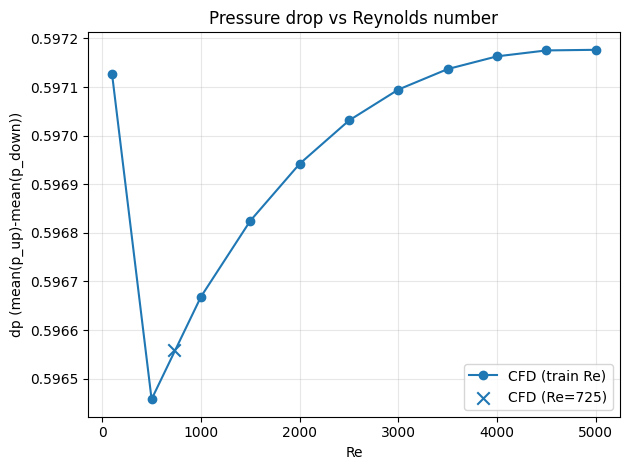

dp_train: {100: 0.5971258846153846, 500: 0.5964576923076923, 1000: 0.5966685384615384, 1500: 0.5968248461538461, 2000: 0.5969421153846151, 2500: 0.5970312307692309, 3000: 0.5970948461538463, 3500: 0.5971370384615384, 4000: 0.5971631923076923, 4500: 0.5971753461538463, 5000: 0.5971766153846154}
dp_true_untrained (Re=725): 0.5965585769230768


In [1]:
# Pressure-drop data extraction and validation (from CFD snapshots)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Re_list = [100,500,1000,1500,2000,2500,3000,3500,4000,4500,5000]
Re_new = 725  # untrained validation point
R = 0.5

# Choose two interior axial locations to compute dp = mean(p_up) - mean(p_down)
# (The exact choice can be tuned; using interior points reduces boundary sensitivity.)

def build_dp_masks(df_template, q_up=0.2, q_down=0.8):
    x = df_template['x'].values
    unique_x = np.unique(x)
    unique_x.sort()

    i_up = int(q_up * (len(unique_x) - 1))
    i_down = int(q_down * (len(unique_x) - 1))

    x_up = unique_x[i_up]
    x_down = unique_x[i_down]

    dx = np.median(np.diff(unique_x)) if len(unique_x) > 1 else 1.0
    tol = max(1e-10, 0.5 * dx)

    mask_up = np.isclose(x, x_up, atol=tol)
    mask_down = np.isclose(x, x_down, atol=tol)

    return mask_up, mask_down, x_up, x_down


def compute_dp_from_df(df, mask_up, mask_down):
    p = df['p'].values.astype(float)
    return float(np.mean(p[mask_up]) - np.mean(p[mask_down]))


data_dir = os.getcwd()

# Build dp masks using one snapshot
base_fn = os.path.join(data_dir, f"steady_state_Re{Re_list[0]}.csv")
df0 = pd.read_csv(base_fn)
mask_up, mask_down, x_up, x_down = build_dp_masks(df0)

print(f"Using dp locations: x_up={x_up:.6g}, x_down={x_down:.6g}")

# Compute dp for training Reynolds numbers
re_vals = []
dp_vals = []
for Re in Re_list:
    fn = os.path.join(data_dir, f"steady_state_Re{Re}.csv")
    df = pd.read_csv(fn)
    dp = compute_dp_from_df(df, mask_up, mask_down)
    re_vals.append(Re)
    dp_vals.append(dp)

# Compute dp for the untrained point (if present)
fn_new = os.path.join(data_dir, f"steady_state_Re{Re_new}.csv")
dp_new = None
if os.path.exists(fn_new):
    df_new = pd.read_csv(fn_new)
    dp_new = compute_dp_from_df(df_new, mask_up, mask_down)

plt.figure()
plt.plot(re_vals, dp_vals, 'o-', label='CFD (train Re)')
if dp_new is not None:
    plt.scatter([Re_new], [dp_new], marker='x', s=80, label=f'CFD (Re={Re_new})')

plt.xlabel('Re')
plt.ylabel('dp (mean(p_up)-mean(p_down))')
plt.title('Pressure drop vs Reynolds number')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

print('dp_train:', dict(zip(re_vals, dp_vals)))
if dp_new is not None:
    print(f'dp_true_untrained (Re={Re_new}): {dp_new}')


## Pressure-drop extraction from CFD snapshots

This notebook computes a consistent pressure-drop metric `dp` directly from the CFD output pressure field (`p` column in `steady_state_Re*.csv`) and plots `dp` vs Reynolds number.

It also reports the untrained validation point (`Re=725`) when the corresponding CSV is available.

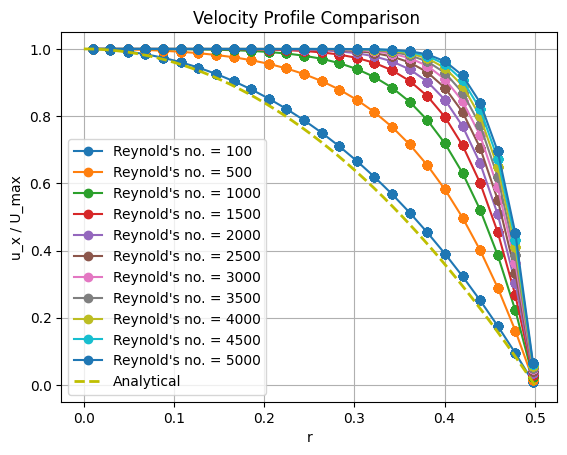

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# List of Reynolds numbers 
Re_list = [100,500, 1000,1500,2000,2500,3000,3500,4000,4500,5000]

R = 0.5

plt.figure()

for Re in Re_list:
    filename = f"steady_state_Re{Re}.csv"
    
    # Load data
    df = pd.read_csv(filename)

    x = df['x'].values
    y = df['y'].values
    ux = df['ux'].values

    x_target = np.median(x)
    mask = np.isclose(x, x_target, atol=1e-1)

    y_slice = y[mask]
    ux_slice = ux[mask]

    # sort by radius
    idx = np.argsort(y_slice)
    r = y_slice[idx]
    ux_sorted = ux_slice[idx]

    # normalize 
    U0 = np.max(ux_sorted)
    ux_norm = ux_sorted/U0

    # plot numerical
    plt.plot(r, ux_norm, 'o-', label=f"Reynold's no. = {Re}")


# analytical solution 
r_analytical = np.linspace(0, R, 200)
ux_analytical = (1 - (r_analytical / R)**2)

plt.plot(r_analytical, ux_analytical, 'y--', linewidth=2, label="Analytical")


plt.xlabel("r")
plt.ylabel("u_x / U_max")
plt.title("Velocity Profile Comparison ")
plt.legend()
plt.grid()

plt.show()